# Elektrokardiyogramları (EKG) Sınıflandırma

<img src='https://upload.wikimedia.org/wikipedia/commons/9/9e/SinusRhythmLabels.svg' width=400>

🧑🏻‍🏫 İlk görevde gördük ki **Tekrarlayan Sinir Ağları sekans tahmin problemleri ile çalışmak için iyi tasarlanmıştır**: gözlemlenen bir veri sekansına dayalı olarak, RNN'ler bundan sonra ne olacağını tahmin etmek için kullanılır (bir sıcaklığın, hisse senedi fiyatının bir sonraki değerini tahmin etme, ... $ \rightarrow $ ***regresyon görevi***).

👉 RNN'leri kullanmanın farklı bir yolunu görelim. Gözlemlenen sekanstan sonra oluşan bir değeri tahmin etmek yerine, ***tüm sekansın kendisini sınıflandıracağız***, sanki tüm sekans belirli bir kategoriye karşılık geliyormuş gibi.

🎯 Egzersiz hedefleri:
- Zamansal verilerle yeni bir uygulama türü keşfedin: sınıflandırma (kalp atışlarını sınıflandıracağız ❤️)
- Farklı RNN mimarilerini deneyin.

_PS: Google Colab kullanmanıza gerek yok_ ❌

## (1) EKG veri seti

* Veriler elektrokardiyogramlara (EKG) karşılık gelir, bunlar temelde kalp atışlarıdır.
    - Her sekans bu nedenle bir amplitüd dizisidir.
    - Bu EKG'ler genellikle kalp arızalarını gözlemlemek için kullanılır!
* Bu veri setinde 87554 kalp atışı vardır ve her biri 0 ile 4 arasında değişen bir kalp atışı türüne karşılık gelir:
    - 0 : Normal atış
    - 1 : Supraventriküler
    - 2 : Ventriküler
    - 3 : Füzyon
    - 4 : Sınıflandırılamayan atışlar

### (1.1) 🎁 Veri setini yükleme

In [1]:
import requests
import io
import numpy as np


# Loading X
response = requests.get('https://d37p7d5kaxknzw.cloudfront.net/projects/ECG_X.npy')
response.raise_for_status()
X = np.load(io.BytesIO(response.content), allow_pickle=True).tolist()

# Loading y
response = requests.get('https://d37p7d5kaxknzw.cloudfront.net/projects/ECG_Y.npy')
response.raise_for_status()
y = np.load(io.BytesIO(response.content), allow_pickle=True).tolist()

### (1.2) 🎁 Bazı EKG'leri görselleştirme

🎁 Veri setindeki her kategori için bir EKG çizmeniz için size bir Python kodu verdik

👩🏻‍⚕️ *Aşağıdaki hücreyi çalıştırın* ve her kategori için bir EKG'nin nasıl göründüğüne dair bir fikir edinin.

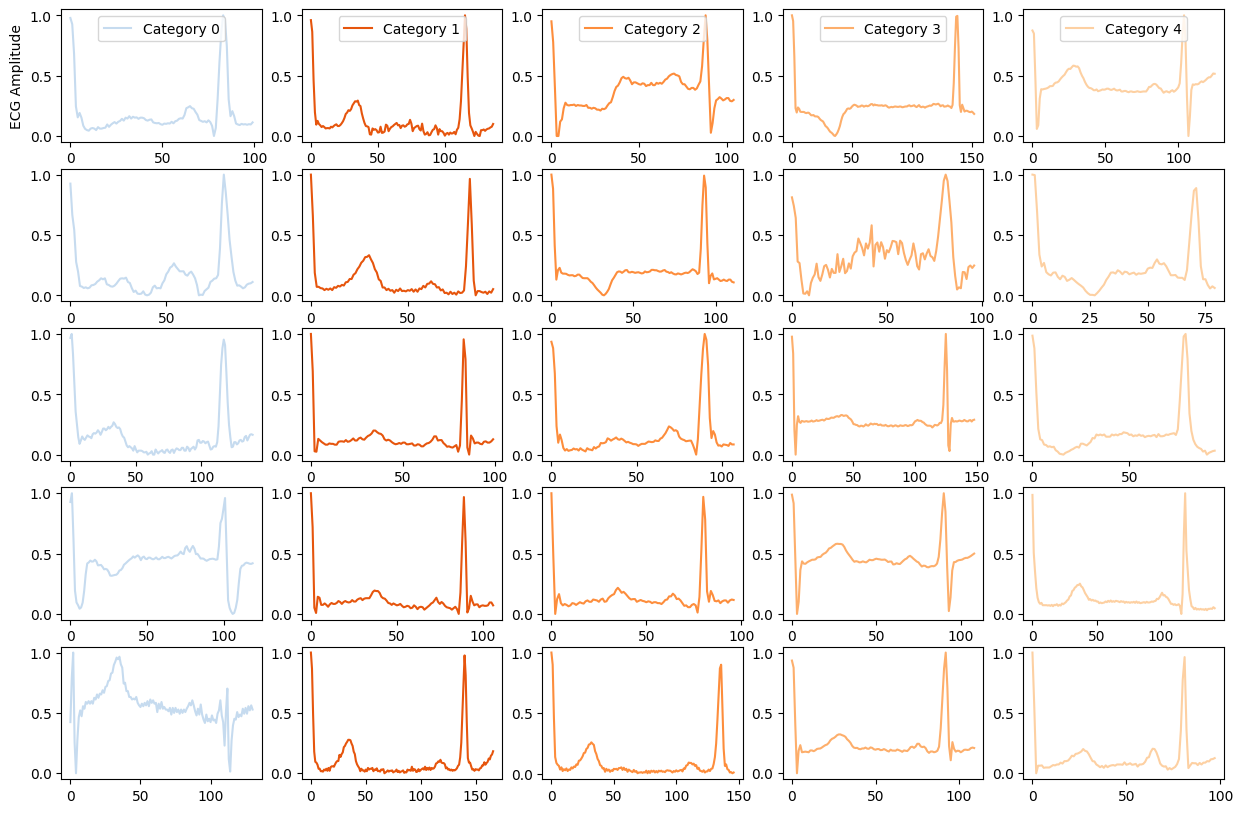

In [2]:
import matplotlib.pyplot as plt

# ------------------------- #
#      Some colormaps       #
# ------------------------- #

cmap = plt.get_cmap("tab20c")
colors_list = cmap.colors


# ------------------------- #
#      Some ECG             #
# ------------------------- #

fix, axs = plt.subplots(5,5, figsize=(15,10))

for i in range(5): # Five examples per category
    for j in range(5): # Iterating over the 5 categories
        idx_C = np.argwhere(np.array(y) == j)  # Collecting the indexes of all the heartbeats of category j
        axs[i,j].plot(X[idx_C[i][0]], label=f'Category {j}', c=colors_list[j+3]) # Plotting the ECG
        # Some cosmetic tricks down below
        if i == 0:
            axs[i,j].legend(loc='upper center')
            if j ==0:
                axs[i,j].set_xlabel('Time')
                axs[i,j].set_ylabel('ECG Amplitude')

### (1.3) 💻 Sekansları doldurma (padding)

🕵🏻‍♂️ Her sekansın, yani her EKG'nin farklı uzunluğa sahip olduğunu (muhtemelen?) fark ettiniz.

❓ **Soru** ❓ Bu gözlemi doğrulamak için veri setindeki sekans uzunluklarının dağılımını çizin.

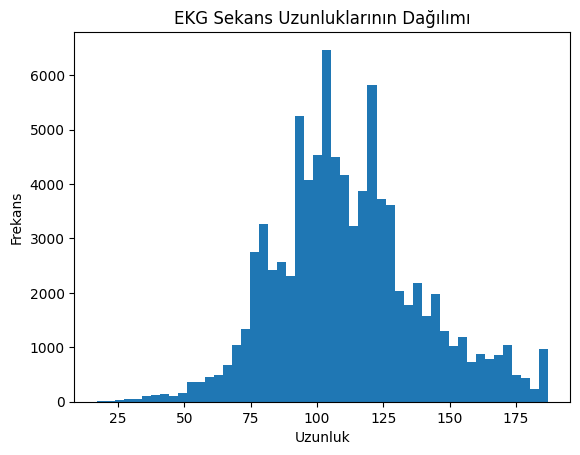

In [3]:
# Her bir EKG sekansının uzunluğunu bul ve çizdir
lengths = [len(seq) for seq in X]
plt.hist(lengths, bins=50)
plt.title('EKG Sekans Uzunluklarının Dağılımı')
plt.xlabel('Uzunluk')
plt.ylabel('Frekans')
plt.show()

🧑🏻‍🏫 Sinir Ağlarının tensörlerle beslendiğini hatırlayın, parti parti. Bu tensörlerin şekli aşağıdaki gibidir:

>`(# SEKANSLAR, sekans başına # GÖZLEM, gözlem başına # ÖZELLİK)`

- `# SEKANSLAR` = $87554$ sekans
- `sekans başına # GÖZLEM` = ❗️***gözlem sayısı bir sekanstan diğerine değişir***❗️ 
- `gözlem başına # ÖZELLİK` = her gözlem sadece $1$ özellik toplar = EKG'nin amplitüdü.

😰 Böyle bir tensöre ***düzensiz tensör*** denir. Hesaplama nedenleriyle, bu bir Tekrarlayan Sinir Ağına beslenemez. 

💡 RNN'lerin düzgün tensörlerle beslenmesi gerekir. Bu nedenle, "***her sekansın boşluklarını doldurmanız***" gerekir. [📚 **`pad_sequences`**](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/sequence/pad_sequences) kullanarak, her sekans sahte değerlerle doldurulacaktır. Sonuç olarak tüm sekanslar aynı uzunlukta olacaktır.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/DL/tensors_in_rnn.png" alt="Tensors in RNN" width="500" height="600">

👨🏻‍🏫 Tekrarlayan Sinir Ağı, bir sıfırın hesaplama nedenleriyle dolgu olarak kullanılan sahte bir değer olduğunu nasıl bilecek? **`Masking`** adında bir katman vardır ve bu katman RNN'e sahte değerleri görmezden gelmesini söyleyecektir. 

💡 `pad_sequences` ile çalışırken en iyi uygulamalar:
* "Eksik değerleri" sekansların sonuna `padding = 'post'` argümanıyla doldurmak daha iyidir
* Ele aldığınız problem için mantıklı olmayan bir dolgu değeri kullanmalısınız. Ağ'ın dolgu değerini diğer değerlerden ayırt etmesi daha kolay olacaktır. _Örneğin, bir kalp atışı negatif olamaz_, bu nedenle burada `value = -1` dolgu değeri kullanabilirsiniz.

❓ **Soru** ❓ X üzerinde 📚 [**`pad_sequences`**](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/sequence/pad_sequences) fonksiyonunu uygulayın.

- Şu argümanları unutmayın: `dtype`, `padding = 'post'` ve `value = -1`
- Doldurulmuş sekansları `X_pad` adında bir değişkende saklayın
- Ve ilk doldurulmuş sekansı yazdırın

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sekansların sonunu (post) -1 ile doldur (kalp atışı genliği -1 olamaz, bu yüzden model bunun sahte olduğunu anlar)
X_pad = pad_sequences(X, dtype='float32', padding='post', value=-1.0)

# İlk doldurulmuş sekansı yazdır
print(X_pad[0])

2026-03-30 17:32:02.967639: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 17:32:02.975887: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 17:32:03.003972: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-30 17:32:03.049343: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-30 17:32:03.098931: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

[ 0.97794116  0.9264706   0.6813725   0.24509804  0.15441176  0.19117647
  0.15196079  0.08578432  0.05882353  0.04901961  0.04411765  0.06127451
  0.06617647  0.06127451  0.04901961  0.07352941  0.06127451  0.06127451
  0.06617647  0.06862745  0.09558824  0.0759804   0.09313726  0.10539216
  0.11519608  0.10294118  0.11764706  0.125       0.14215687  0.12745099
  0.15196079  0.14460784  0.16421568  0.14460784  0.15931372  0.15196079
  0.15441176  0.14215687  0.15196079  0.15196079  0.14705883  0.13235295
  0.12745099  0.13480392  0.13725491  0.1127451   0.10784314  0.10539216
  0.10784314  0.09803922  0.09313726  0.10294118  0.1004902   0.10539216
  0.10294118  0.11764706  0.10539216  0.12254902  0.12745099  0.14215687
  0.14705883  0.14460784  0.1740196   0.23039216  0.23774509  0.24754901
  0.23039216  0.2254902   0.1985294   0.1764706   0.13235295  0.125
  0.11764706  0.12254902  0.1127451   0.12990196  0.11519608  0.08333334
  0.          0.06617647  0.30637255  0.6127451   0.8602

🧪 Doğru şekilde doldurduysanız, `X_pad`'in şekli $ (87554, 187) $'ye eşit olmalıdır

In [5]:
X_pad.shape

(87554, 187)

In [6]:
from nbresult import ChallengeResult

print(f"X_pad.shape = {X_pad.shape}")

result = ChallengeResult('padded',
                         padded_shape = X_pad.shape)
result.write()
print(result.check())

X_pad.shape = (87554, 187)

============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/cem/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/cem/code/gcemozdogan/S18D5-S-data-electrocardiograms/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 1 item

test_padded.py::TestPadded::test_variable_padded_shape PASSED            [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/padded.pickle

git commit -m 'Completed padded step'

git push origin master



☝️ Bir boyut eksik, sonuncusu (gözlem başına özellik sayısına karşılık gelen)

❓ **Soru** ❓ Bu sorunu çözmek için `Numpy`'den `expand_dims` fonksiyonunu kullanarak son boyutu genişletin

In [7]:
# X_pad'in şeklini (87554, 187) formatından (87554, 187, 1) formatına genişlet
X_pad = np.expand_dims(X_pad, axis=-1)

# Assert testini geçmeli
assert(X_pad.shape == (87554, 187, 1))

In [8]:
assert(X_pad.shape == (87554, 187, 1))

### (1.4) 💻 Kategorik hedefleri kodlama

❓ **Soru** ❓ `y` etiketleri one-hot-encoded kategorilere dönüştürülmeli. Uygun Keras fonksiyonunu kullanarak `y`'yi kategorilere dönüştürün ve sonucu `y_cat` adında bir değişkende saklayın

In [9]:
from tensorflow.keras.utils import to_categorical

# 5 sınıf olduğu için num_classes=5
y_cat = to_categorical(y, num_classes=5)

## (2) 💻 RNN modelleme

❓ **Soru** ❓ Veri setinizi (elektrokardiyogramları) eğitim ve test seti arasında bölün (80/20 oranı).

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pad, y_cat, test_size=0.20, random_state=42)

### (2.1) 💻 GRU ve LSTM

👉 Önceki görevle karşılaştırıldığında, her sekans birçok gözlem içerir (187 zaman birimi) ve sezginiz size kalp hastalıklarını tespit etmek için hepsinin önemli olduğunu söylemelidir (sadece en "son" olanları değil).

🚀 *Kaybolan gradyan probleminden kaçınma* yetenekleri ile **LSTM (= Uzun Kısa Süreli Bellek)** veya **GRU (= Kapılı Tekrarlayan Birim)** modeli, SimpleRNN'den daha çok tercih edilmelidir.

❓ **Soru (RNN mimarisi)** ❓ 
* Aşağıdaki katmanları içeren bir model yazın:
    - `mask_value`'su verilerinizi doldurduğunuz değere karşılık gelen bir Masking katmanı (muhtemelen önerdiğimiz gibi negatif bir değer) - bu katman sadece ağa hesaplama yapay öğesini dikkate almamasını söyleyecek
    - her biri 20 birimli ve aktivasyon fonksiyonu olarak `tanh` kullanan iki yığılmış `GRU` katmanı
    - 50 birimli bir yoğun katman
    - %20 düşürme oranına sahip bir dropout katmanı
    - son (tahmin edici) yoğun katman.
* Modelin özetini yazdırın

In [11]:
from tensorflow.keras import Sequential, layers

model = Sequential()

# 1. Masking Katmanı (-1 değerlerini yoksay)
model.add(layers.Masking(mask_value=-1.0, input_shape=(187, 1)))

# 2. İki adet yığılmış (stacked) GRU Katmanı
# İlk GRU bir sonrakine dizi (sequence) göndermeli, bu yüzden return_sequences=True
model.add(layers.GRU(20, activation='tanh', return_sequences=True))
model.add(layers.GRU(20, activation='tanh'))

# 3. Dense ve Dropout Katmanları
model.add(layers.Dense(50, activation='relu'))
model.add(layers.Dropout(0.2))

# 4. Çıkış Katmanı (5 sınıf için softmax)
model.add(layers.Dense(5, activation='softmax'))

model.summary()

/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-03-30 17:35:17.931430: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-30 17:35:17.932365: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 187, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 187, 20)        │         1,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 20)             │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         1,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,205 (20.33 KB)

 Trainable params: 5,205 (20.33 KB)

 Non-trainable params: 0 (0.00 B)

❓ **Soru (Eğitim)** ❓ Modelinizi derleyin ve eğitin. 

<u>Uyarı:</u> GPU'lar olsa bile epoch başına çok uzun sürebileceğini fark edeceksiniz. RNN'ler, doğası gereği CNN'lerden daha zor dağıtılır. Gerçekten de GPU'lar `trainable_params` büyük olduğunda (burada durum bu değil) veya `batch_size` büyük olduğunda en iyi çalışır.

- Her epoch süresini azaltmak için daha büyük bir batch size kullanın (örn. 128)

- Ayrıca 1'e eşit çok küçük bir patience da yeterli olmalıdır. Bunun nedeni, nispeten büyük bir `batch_size` ile bile, çok sayıda sekansınızın ve dolayısıyla epoch başına çok sayıda optimizasyonunuzun olmasıdır

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

# Derleme: Çoklu sınıflandırma olduğu için categorical_crossentropy kullanıyoruz
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

# Eğitim süresini kısaltmak için sabrı çok düşük (1) tutuyoruz
es = EarlyStopping(patience=1, restore_best_weights=True)

# Eğitimi başlat (Batch_size 128 olarak ayarlandı)
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=20,
                    batch_size=128,
                    callbacks=[es],
                    verbose=1)

Epoch 1/20


2026-03-30 17:35:32.550105: E tensorflow/core/util/util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


438/438 ━━━━━━━━━━━━━━━━━━━━ 47s 102ms/step - accuracy: 0.8228 - loss: 0.7085 - val_accuracy: 0.8301 - val_loss: 0.6478
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 44s 100ms/step - accuracy: 0.8266 - loss: 0.6714 - val_accuracy: 0.8301 - val_loss: 0.6475
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.8266 - loss: 0.6692 - val_accuracy: 0.8301 - val_loss: 0.6478


❓ **Soru (Değerlendirme)** ❓ Modelinizi test verileri üzerinde değerlendirin.

In [13]:
# Test seti üzerinde değerlendirme yap
res = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Seti Doğruluğu (Accuracy): %{res[1]*100:.2f}")

Test Seti Doğruluğu (Accuracy): %82.94


## (3) 💻 Temel Model

🧑🏻‍🏫 ***Bir sınıflandırma görevinde, temel model, test setindeki tüm öğeler için eğitim setinin en sık görülen sınıfını tahmin etmektir.***

Peki, `y_test`'teki her EKG için `y_train`'deki en olası kategoriyi tahmin eden bir temel modelin doğruluğu nedir?

* 🎁 Sizin için çok sınıflı bir sınıflandırma görevinin temel doğruluğunu hesaplamak için kodu aşağıda yazdık.
    * 🧑🏻‍🎓 Hücreleri sırayla çalıştırarak kodu anladığınızdan emin olun
* 🕵️‍♀️ Temel doğruluğu RNN modeliyle karşılaştırın

In [14]:
# As a reminder, here is y_train "encoded"
y_train

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])

In [15]:
# Let's compute the occurencies per heartbeat category in the train set
occurencies_per_heartbeat_category_train = np.sum(y_train, axis=0)
occurencies_per_heartbeat_category_train

array([57947.,  1801.,  4593.,   507.,  5195.])

In [16]:
# You can see that the first category is the most frequent one in the train set
most_frequent_category_train = np.argmax(occurencies_per_heartbeat_category_train)
most_frequent_category_train

0

In [17]:
# We can compute the occurencies per heartbeat category in the test set as well
occurencies_per_heartbeat_category_test = np.sum(y_test, axis=0)
occurencies_per_heartbeat_category_test

array([14524.,   422.,  1195.,   134.,  1236.])

In [18]:
# Let's predict the most_frequent_category_train category for all the ECG in the test set
number_of_correct_predictions = occurencies_per_heartbeat_category_test[most_frequent_category_train]
number_of_correct_predictions

14524.0

In [19]:
# "Evaluating" the baseline model: in the test set, a baseline model will always predict
# the most frequent class found in the train set
baseline_accuracy = number_of_correct_predictions/len(y_test)
print(f'Baseline accuracy = {round(baseline_accuracy,3)}')

Baseline accuracy = 0.829


👆 Temelde, daha önce tasarladığımız RNN, en mevcut kategoriyi tahmin eden bir temel model kadar iyi/kötü çıktı...

🕵🏻 RNN modelinin tahminlerini derinlemesine inceleyelim.

❓ **Soru** ❓ RNN modeli tarafından hangi kategorilerin tahmin edildiğini kontrol etmek için *predict* fonksiyonunu kullanın. Tahminlerin dağılımını eğitim setindeki sınıfların dağılımları ile karşılaştırın. Ne fark ediyorsunuz?

In [20]:
# Modelin test seti üzerindeki tahminlerini al (olasılıklar döner)
y_pred_probs = model.predict(X_test)

# En yüksek olasılığa sahip sınıfı seç (0, 1, 2, 3 veya 4)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Tahminlerin dağılımını yazdır
unique, counts = np.unique(y_pred_classes, return_counts=True)
print("Modelin Tahmin Ettiği Sınıf Dağılımı:")
print(dict(zip(unique, counts)))

# Gerçek test setindeki dağılımı yazdır
y_test_classes = np.argmax(y_test, axis=1)
unique_test, counts_test = np.unique(y_test_classes, return_counts=True)
print("\nGerçek Test Setindeki Sınıf Dağılımı:")
print(dict(zip(unique_test, counts_test)))

548/548 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step
Modelin Tahmin Ettiği Sınıf Dağılımı:
{0: 17511}

Gerçek Test Setindeki Sınıf Dağılımı:
{0: 14524, 1: 422, 2: 1195, 3: 134, 4: 1236}


## (4) 📚 Sonuç

🤨 RNN modeli eğitim setindeki kalp atışlarının orijinal dağılımına son derece yakın frekanslar tahmin ediyor... Bu neden böyle?

* RNN oldukça ***dengesiz bir veri seti*** üzerinde eğitildi. En çok temsil edilen kategoriyi (normal kalp atışları) azaltarak ve az temsil edilen kategorileri artırarak veri setini yeniden dengeleyebiliriz... Ama bu RNN üzerine olan bu bölümün odak noktası değil :)
* ***Sinir ağları daha büyük veri setleri gerektirir***. Mevcut veri seti Sinir Ağlarının ondan fark edilebilir gerçekleri öğrenmesi için *çok küçük*.
* Bir hasta için EKG kategorisini tahmin etmek kolay bir görev değil. RNN'nin "sağlıklı bir EKG'nin" ne olduğuna dair kalıpları öğrenmesine yardımcı olmak için ***her hasta için birden fazla EKG'ye sahip olmamız gerekir***. Maalesef, bu veri setinde hasta başına sadece ***bir*** kalp atışı vardır.

❌ Burada sonuçları iyileştirmeye çalışmayın.

🧑🏻‍🏫 Size öğrettiğimiz ve burada tekrar tekrar tekrarlayacağımız bir ders:
* **Modelinizi bir temel modelle karşılaştırmadıkça herhangi bir "iyi" doğruluktan memnun olmayın!**

***

🏁 Tebrikler 🏁

💾 Kodunuzu push etmeyi unutmayın


* *git add classify_electrocardiograms.ipynb*
* *git commit -m "EKG için RNN'leri seviyorum"* veya istediğiniz anlamlı mesaj
* *git push origin master*

🚀 *Sıcaklık Tahmin* görevine geçme zamanı!